# Block 2: LSTM for Multi-Step Time Series Forecasting
## Hochfrequenz AI Workshop

**Objective:** Build LSTM models to predict next 24 hours of household electricity consumption

**Key Concepts:** ANNs → RNNs → LSTMs, Sequence modeling, Multi-step forecasting

**Models:** LSTM (single-step) → LSTM (multi-step) → Compare with Block 1 XGBoost

**Transformer's architecture excel at sequential data**

First run with incomplete data is not so good. Why tune model if I dont have the data? focus on getting nice data

## Theory: From ANNs to LSTMs (TO TRANSFORMERS)

### Why Standard Neural Networks Fail at Time Series

**Problem:** Traditional ANNs (Artificial Neural Networks) treat each input independently:
- They don't remember previous inputs
- Can't capture temporal dependencies
- Example: Predicting consumption at 6 PM requires knowing consumption at 5 PM, 4 PM, etc.

### Recurrent Neural Networks (RNNs)

**Solution:** RNNs maintain a "hidden state" that carries information from previous time steps
- Each time step updates the hidden state
- Hidden state = memory of what came before

**Problem with basic RNNs:** Vanishing gradient problem
- Can't remember patterns from distant past (e.g., 24 hours ago)
- Gradients become too small during backpropagation

### LSTM (Long Short-Term Memory)

**Solution:** LSTMs use gates to control what to remember and forget:

1. **Forget Gate:** Decides what to discard from memory
2. **Input Gate:** Decides what new information to store
3. **Output Gate:** Decides what to output from memory
4. **Cell State:** Long-term memory (can carry information across many time steps)

**Why LSTMs Win for Energy Forecasting:**
- Remember daily patterns (consumption 24h ago)
- Capture weekly patterns (weekday vs weekend)
- Learn seasonal trends
- Handle multiple time scales simultaneously

# 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# TensorFlow/Keras imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print(f"✅ All libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")

✅ All libraries imported successfully
TensorFlow version: 2.20.0


### 1.1 Load Data (Recap from Block 1)

We'll use the same German household consumption data, but prepare it differently for LSTM (sequences instead of feature vectors)

### 1.1.2 Mount Google Drive
Run these cells only if working from google colab. When working on your machine you'll have access to the folders with the data.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#testing
import h5py

#adapt name
path = '/content/drive/MyDrive/04 Workshop Materials (Shared)/Companies/Hochfrequenz GmbH/Workshop Day/2018 Data 60min.hdf5'  
f = h5py.File(path, 'r')

#Top‑level groups (e.g. 'NOPV', 'WITHPV', 'MISCSUBSTATION')
print(list(f.keys()))

g = f['NO_PV']                    # example - changed from NOPV to NO_PV
print(list(g.keys()))            # e.g. ['SFH3', 'SFH4', ...]

sfh3 = g['SFH3']
print(list(sfh3.keys()))         # e.g. ['HOUSEHOLD', 'HEATPUMP']

household = sfh3['HOUSEHOLD']
print(list(household.keys()))    # column names, e.g. ['index', 'P_TOT', 'Q_TOT', 'U_1', ...]
nopv = f['NO_PV']
sfh3 = nopv['SFH3']
household = sfh3['HOUSEHOLD']

timestamps = household['table']['index'][:]          # UNIX seconds
p_active   = household['table']['P_TOT'][:]          # W, active power [file:68]

def load_household_power(f, house='SFH3', top='NO_PV', meter='HOUSEHOLD', column='P_TOT'):
    grp = f[top][house][meter]
    return grp['table']['index'][:], grp['table'][column][:]

print(p_active)
inspect = load_household_power(f, house='SFH3', top='NO_PV', meter='HOUSEHOLD', column='P_TOT')
print(inspect)

### 1.1.3 Read HDF5 data

In [2]:
import h5py
import pandas as pd
import numpy as np
from datetime import datetime

# 1. Load real data from HDF5
def load_wpuq_household(filepath, house='SFH3', top='NO_PV', meter='HOUSEHOLD'):
    """Load household or heat pump power consumption from WPuQ dataset"""
    with h5py.File(filepath, 'r') as f:
        grp = f[top][house][meter]['table']

        timestamps_unix = grp['index'][:]        # UNIX seconds
        p_active = grp['P_TOT'][:]               # Active power in watts [file:68]
        q_reactive = grp['Q_TOT'][:]             # Reactive power (optional)

    # Convert UNIX timestamps to datetime
    timestamps = pd.to_datetime(timestamps_unix, unit='s')

    # Build DataFrame (similar structure to your dummy data)
    data = pd.DataFrame({
        'timestamp': timestamps,
        'consumption': p_active,              # Your main metric (W)
        'reactive_power': q_reactive,
        'hour': timestamps.hour,
        'day_of_week': timestamps.dayofweek,
        'month': timestamps.month,
        'is_weekend': (timestamps.dayofweek >= 5).astype(int)
    })

    data.set_index('timestamp', inplace=True)
    return data

# 2. Load and inspect
# filepath = '/content/drive/MyDrive/04 Workshop Materials (Shared)/Companies/Hochfrequenz GmbH/Workshop Day/2019 Data 60min.hdf5'
filepath18 = '/Users/brunocopa/Public/Companies/MIRAI/Workshops/Hochfrequenz GmbH/Shared/energy-demand/data/2018 Data 60min.hdf5'
data_2018 = load_wpuq_household(filepath18, house='SFH3', meter='HOUSEHOLD')
filepath19 = '/Users/brunocopa/Public/Companies/MIRAI/Workshops/Hochfrequenz GmbH/Shared/energy-demand/data/2019 Data 60min.hdf5'
data_2019 = load_wpuq_household(filepath19, house='SFH3', meter='HOUSEHOLD')

# 3. Merge data
# 2018 data has Nan's between Jan and April
data_2018 = data_2018[data_2018.index.month >= 6]
#data = pd.merge(data_2018, data_2019, how='outer')
#data = data_2019
data = pd.concat([data_2018, data_2019], axis=0)


print(f"Dataset shape: {data.shape}")
print(f"Date range: {data.index.min()} to {data.index.max()}")
print(f"\nFirst 5 rows:")
print(data.head(n=5))
print(f"\nConsumption statistics:")
print(data['consumption'].describe())

Dataset shape: (13896, 6)
Date range: 2018-06-01 00:00:00 to 2019-12-31 23:00:00

First 5 rows:
                     consumption  reactive_power  hour  day_of_week  month  \
timestamp                                                                    
2018-06-01 00:00:00   107.563833       46.698722     0            4      6   
2018-06-01 01:00:00   128.185722        5.180278     1            4      6   
2018-06-01 02:00:00    87.512389       -9.645250     2            4      6   
2018-06-01 03:00:00   184.230084       72.585944     3            4      6   
2018-06-01 04:00:00   118.397889       35.135694     4            4      6   

                     is_weekend  
timestamp                        
2018-06-01 00:00:00           0  
2018-06-01 01:00:00           0  
2018-06-01 02:00:00           0  
2018-06-01 03:00:00           0  
2018-06-01 04:00:00           0  

Consumption statistics:
count    13896.000000
mean       225.523714
std        242.290152
min         43.396639
25%   

### Add temperature/combine data
Our data came with the weather data as a different file, so we have to extract it and merge it with our current data_frame

In [3]:
def load_weather(filepath):
    """Load ambient temperature from weather data file"""
    with h5py.File(filepath, 'r') as f:

        table = f['WEATHER_SERVICE']['IN']['WEATHER_TEMPERATURE_TOTAL']['table']
        print(f"Dataset shape: {table.shape}")
        print(f"Available columns (fields): {table.dtype.names}")
        # 2. Load Index

        ts = table['index'][:]
        print(ts)
        temps = table['TEMPERATURE:TOTAL'][:] 

    timestamps = pd.to_datetime(ts, unit='ns')
    temps_df = pd.DataFrame({
        'timestamp':timestamps, 
        'month': timestamps.month,
        'temperature': temps
    })
    temps_df.set_index('timestamp', inplace=True)
    
    # Resample to hourly (H) to match consumption data
    return temps_df.resample('H').mean()

weather_2018 = load_weather('/Users/brunocopa/Public/Companies/MIRAI/Workshops/Hochfrequenz GmbH/Shared/energy-demand/data/2018 Weather Data.hdf5')
weather_2019 = load_weather('/Users/brunocopa/Public/Companies/MIRAI/Workshops/Hochfrequenz GmbH/Shared/energy-demand/data/2019 Weather Data.hdf5')
weather_2018 = weather_2018[weather_2018.index.month >= 6]
weather_data = pd.concat([weather_2018, weather_2019], axis=0)

print(weather_2019.head())
# You only need the 'temperature' column from the weather data
data = data.join(weather_data[['temperature']], how='left').interpolate()  # Fill gaps
print(data.head())

Dataset shape: (49079,)
Available columns (fields): ('index', 'TEMPERATURE:TOTAL')
[1514764800000000000 1514768400000000000 1514772000000000000 ...
 1546296600000000000 1546296900000000000 1546297200000000000]
Dataset shape: (104549,)
Available columns (fields): ('index', 'TEMPERATURE:TOTAL')
[1546297200000000000 1546297800000000000 1546298100000000000 ...
 1577832600000000000 1577832900000000000 1577833200000000000]
                     month  temperature
timestamp                              
2018-12-31 23:00:00   12.0     8.790000
2019-01-01 00:00:00    1.0     8.011111
2019-01-01 01:00:00    1.0     7.720000
2019-01-01 02:00:00    1.0     7.000000
2019-01-01 03:00:00    1.0     7.170000
                     consumption  reactive_power  hour  day_of_week  month  \
timestamp                                                                    
2018-06-01 00:00:00   107.563833       46.698722     0            4      6   
2018-06-01 01:00:00   128.185722        5.180278     1           

### 1.1.4 Generate realistic synthetic German household consumption data

This mimics the Nature Scientific Data dataset structure

In [ ]:
np.random.seed(42)

# Generate 2 years of hourly data
date_range = pd.date_range(start='2018-05-01', end='2020-12-31', freq='H')
n_samples = len(date_range)

# Create realistic consumption pattern
data = pd.DataFrame({
    'timestamp': date_range,
    'hour': date_range.hour,
    'day_of_week': date_range.dayofweek,
    'month': date_range.month,
    'is_weekend': (date_range.dayofweek >= 5).astype(int)
})

# Base consumption pattern (W) - typical German household
# Morning peak (~7 AM), evening peak (~6-7 PM), low at night
hourly_pattern = np.array([
    300, 280, 250, 240, 250, 350, 550, 700,  # Night to morning
    600, 500, 450, 420, 430, 480, 550, 600,  # Midday
    700, 800, 750, 700, 650, 600, 550, 400   # Evening to night
])

# Apply hourly pattern
data['consumption_base'] = hourly_pattern[data['hour']]

# Add seasonal variation (winter = higher consumption)
seasonal_factor = 1.0 + 0.3 * np.sin(2 * np.pi * (data['month'] - 2) / 12)
data['consumption_seasonal'] = data['consumption_base'] * seasonal_factor

In [ ]:

# Add weekend effect (lower consumption)
data['consumption_adjusted'] = data['consumption_seasonal'] * np.where(data['is_weekend'] == 1, 0.85, 1.0)

# Add random noise and weather effects
data['consumption'] = data['consumption_adjusted'] + np.random.normal(0, 50, n_samples)
data['consumption'] = data['consumption'].clip(lower=50)  # No negative consumption

# Create a simple temperature proxy (correlates with season)
data['temperature'] = 15 + 8 * np.sin(2 * np.pi * (data['month'] - 2) / 12) + np.random.normal(0, 2, n_samples)

# Set timestamp as index
data.set_index('timestamp', inplace=True)

print(f"Dataset shape: {data.shape}")
print(f"Date range: {data.index.min()} to {data.index.max()}")
print(f"\nFirst 5 rows:")
print(data.head())
print(f"\nConsumption statistics:")
print(data['consumption'].describe())


# 2. Prepare Data for LSTM (Sequence Format) 

**Key Difference from Block 1:**
- Block 1: Each row = one prediction: features → target. (no time dependency!)
- Block 2: Sequences → predictions (lookback window → forecast horizon)

If you feed the LSTM a sliding window of the past T hours of raw (or log) consumption, 
then the network already sees: 1h ago, 2h ago, …, Th ago. Which means the model sees the "sequence"
of consumption values already, and therefore no need to manually create the sequence 
format as in the previous block.

**LSTM Input Shape:** `(samples, time_steps, features)`
- `samples`: Number of training examples
- `time_steps`: Lookback window (e.g., 24 hours)
- `features`: Number of variables (consumption, temperature, hour, etc.)

### Part of Pre-Processing step from Block 1. Homework: How well does the model perform with NaN's? (Hint: dirty data propagates) (This should be in block 1 as well)

In [4]:
def create_sequences(data, lookback=24, forecast_horizon=1):
    """
    Convert time series to supervised learning format for LSTM. 

    Parameters:
    -----------
    data : numpy array
        Time series data (shape: samples x features)
    lookback : int
        Number of past time steps to use as input (default: 24 hours)
    forecast_horizon : int
        Number of future time steps to predict (default: 1 hour)

    Returns:
    --------
    X : numpy array (samples, lookback, features)
        Input sequences
    y : numpy array (samples, forecast_horizon)
        Target sequences
    """
    X, y = [], []
    for i in range(len(data) - lookback - forecast_horizon + 1):
        X.append(data[i:i+lookback])  # Input: 24 hours
        y.append(data[i+lookback:i+lookback+forecast_horizon, 0])  # Target: consumption only
    return np.array(X), np.array(y)

### 2.2 Train-Test Split (Chronological)

In [5]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler

# 1. Setup Feature Columns
# Ensure 'consumption' is FIRST so create_sequences grabs it as the target
feature_cols = ['consumption', 'hour', 'day_of_week', 'temperature', 'is_weekend']

# 2. Log-Transform Target (Consumption)
# We do this globally because it's a mathematical transformation, not a statistical one learned from data
data['consumption'] = np.log(data['consumption']) # or np.log1p if you have zeros
print(data['consumption'].describe())

# 3. Split Raw Data Chronologically (80/20)
# We work with the numpy values directly
raw_data_matrix = data[feature_cols].values
split_idx = int(len(raw_data_matrix) * 0.8)

train_data_raw = raw_data_matrix[:split_idx]
test_data_raw  = raw_data_matrix[split_idx:]

print(f"Raw Train shape: {train_data_raw.shape}")
print(f"Raw Test shape:  {test_data_raw.shape}")


count    13897.000000
mean         5.173562
std          0.600251
min          3.770382
25%          4.825025
50%          5.066886
75%          5.364662
max          8.293838
Name: consumption, dtype: float64
Raw Train shape: (11117, 5)
Raw Test shape:  (2780, 5)


### 2.1 Scaling Features

Strictly speaking we perform scaling after splitting the data into train/val/test batches, using **only the train/val data** because otherwise we're leaking information from the test set into the training. However, 

#### OPTION 1: log-scale target variable and scale the rest with MinMaxScaler

This still doesn't scale the target variable into a deep learning friendly range (order of maginuted should be similar across all input features). 

Try scaling the log-scale of the target variable (with the corresponding double-descaling after inference) and see if you can improve the predictive accuracy.

```python
scaler = MinMaxScaler()
feature_cols = ['hour', 'day_of_week', 'temperature', 'is_weekend']
data['consumption'] = np.log(data['consumption'])
target_log = data['consumption'].values.reshape(-1, 1) # Reshape to (N, 1) for concatenation
```
Concatenate: [Target (Log), Features (Scaled)]
We put target first (index 0) so your create_sequences function works correctly
```python
data_features = data[feature_cols].values
data_scaled_no_target = scaler.fit_transform(data_features)
data_scaled = np.hstack([target_log, data_scaled_no_target])
feature_cols = ['consumption'] + feature_cols # add back target as a feature to ensure consitency when building the model
```


In [6]:
# 1. Initialize Scaler (RobustScaler is good for outliers. Now that we've gotten rid of the outliers, we prioritize a smaller
# range for the input features (from 0 to 1))
scaler = MinMaxScaler()

# 2. Fit and Transform TRAIN data
train_data_scaled = scaler.fit_transform(train_data_raw)

# 3. Transform TEST data (using stats from Train)
test_data_scaled = scaler.transform(test_data_raw)

print("Scaling complete. Test data scaled using Train statistics.")

Scaling complete. Test data scaled using Train statistics.


### 2.2 Create Sequences for Single-Step Forecasting (1 hour ahead)

In [7]:
lookback = 24
forecast_horizon = 1

# 1. Create Train Sequences
X_train, y_train = create_sequences(train_data_scaled, lookback=lookback, forecast_horizon=forecast_horizon)

# 2. Create Test Sequences
X_test, y_test = create_sequences(test_data_scaled, lookback=lookback, forecast_horizon=forecast_horizon)

print(f"LSTM Data Ready:")
print(f"  X_train: {X_train.shape} (samples, time, features)")
print(f"  y_train: {y_train.shape} (samples, horizon)")
print(f"  X_test:  {X_test.shape}")
print(f"  y_test:  {y_test.shape}")

LSTM Data Ready:
  X_train: (11093, 24, 5) (samples, time, features)
  y_train: (11093, 1) (samples, horizon)
  X_test:  (2756, 24, 5)
  y_test:  (2756, 1)


# 3. Build LSTM Model (Single-Step Forecasting)

**Architecture:**
- Input: (24, 5) - 24 hours of 5 features
- LSTM Layer 1: 64 units, return sequences (for stacking)
- Dropout: 20% (prevent overfitting)
- LSTM Layer 2: 32 units
- Dense: 16 units (ReLU activation)
- Output: 1 unit (next hour consumption)

**OPTUNA**

Deciding upon the ANN's architecture is an optimization problem with infinite combinations. Instead of randomly 
trying different architectures (or following some heuristics) we use Optuna to find the best architecture. (or any other solver)

In [8]:
# Build LSTM model
lstm_model = Sequential([
    layers.LSTM(64*2, return_sequences=True, input_shape=(lookback, len(feature_cols)), name='lstm_1'),
    layers.Dropout(0.2, name='dropout_1'),
    layers.LSTM(32*2, name='lstm_2'),
    layers.Dropout(0.2, name='dropout_2'),
    layers.Dense(16*2, activation='relu', name='dense_1'),
    layers.Dense(16*1, activation='relu', name='dense_2'),
    layers.Dense(1, name='output')  # Single output: next hour consumption
], name='LSTM_Single_Step')

# Compile model
lstm_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Model summary
print(lstm_model.summary())

# Count parameters
total_params = lstm_model.count_params()
print(f"\nTotal trainable parameters: {total_params:,}")

Model: "LSTM_Single_Step"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 24, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,641 (471.25 KB)

 Trainable params: 120,641 (471.25 KB)

 Non-trainable params: 0 (0.00 B)

None

Total trainable parameters: 120,641


# 4. Train LSTM Model

In [9]:
# Define callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Train model
print("Training LSTM model...\n")
history = lstm_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ Training complete!")

Training LSTM model...

Epoch 1/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0166 - mae: 0.0919 - val_loss: 0.0139 - val_mae: 0.0861
Epoch 2/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0140 - mae: 0.0834 - val_loss: 0.0126 - val_mae: 0.0802
Epoch 3/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0128 - mae: 0.0793 - val_loss: 0.0126 - val_mae: 0.0780
Epoch 4/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0125 - mae: 0.0783 - val_loss: 0.0124 - val_mae: 0.0779
Epoch 5/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0120 - mae: 0.0767 - val_loss: 0.0113 - val_mae: 0.0769
Epoch 6/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0117 - mae: 0.0758 - val_loss: 0.0110 - val_mae: 0.0762
Epoch 7/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0114 - mae: 0.0747 - val_loss: 0.0116 - val_mae: 0.0784
Epoch 8/50
278/278 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0113 - mae: 0.0745 - val_loss: 0.0109 - val_mae: 0.0759
Epoch 9/50
278/278 ━━━━━

## 4.1 Visualize Training History

Overfitting, hyperparameter tuning...

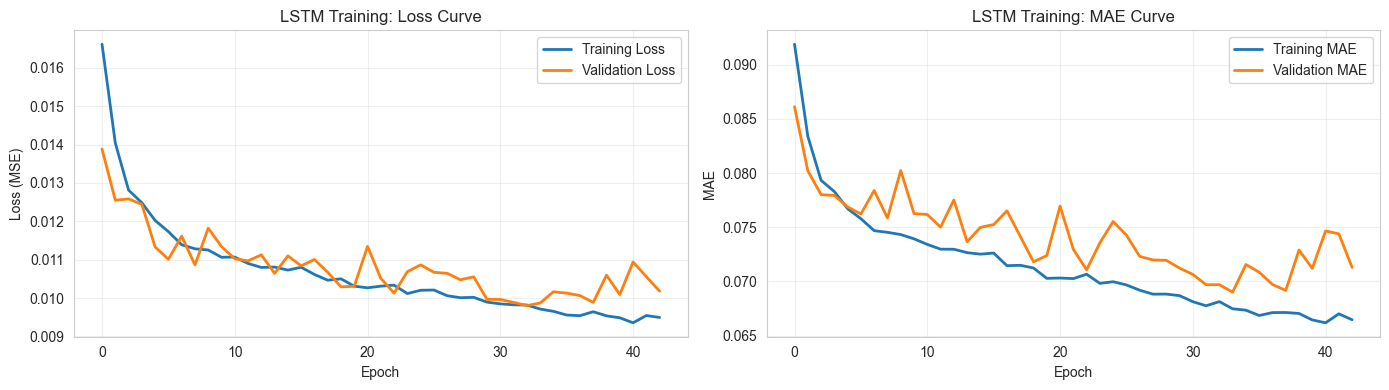


Final Training Loss: 0.009496
Final Validation Loss: 0.010180
Overfitting check: ✅ Good generalization


In [10]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('LSTM Training: Loss Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('LSTM Training: MAE Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
print(f"\nFinal Training Loss: {final_train_loss:.6f}")
print(f"Final Validation Loss: {final_val_loss:.6f}")
print(f"Overfitting check: {'⚠️ Possible overfitting' if final_train_loss < final_val_loss * 0.7 else '✅ Good generalization'}")

# 5. Evaluate LSTM on Test Set

In [11]:
# Predict on test set, remember it was trained to predict log(kWh)
lstm_pred_test_scaled = lstm_model.predict(X_test, verbose=0)

# Inverse transform to original scale 
# Need to reconstruct full feature matrix for inverse_transform
y_test_full = np.zeros((len(y_test), len(feature_cols)))
y_test_full[:, 0] = y_test.flatten()  # Consumption is first feature
#y_test_original = y_test_full
y_test_original = scaler.inverse_transform(y_test_full)[:, 0]  # scaler.inverse_transform

lstm_pred_full = np.zeros((len(lstm_pred_test_scaled), len(feature_cols)))
lstm_pred_full[:, 0] = lstm_pred_test_scaled.flatten()
lstm_pred_original = scaler.inverse_transform(lstm_pred_full)[:, 0] # scaler.inverse_transform

# Remember we log-scale the target as well?
y_test_original = np.exp(y_test_original)
lstm_pred_original = np.exp(lstm_pred_original)

print(y_test_original)
print(lstm_pred_original)

# Calculate metrics
lstm_mae = mean_absolute_error(y_test_original, lstm_pred_original)
lstm_rmse = np.sqrt(mean_squared_error(y_test_original, lstm_pred_original))
lstm_r2 = r2_score(y_test_original, lstm_pred_original)

print("="*60)
print("LSTM SINGLE-STEP FORECAST PERFORMANCE")
print("="*60)
print(f"MAE:  {lstm_mae:.2f} W")
print(f"RMSE: {lstm_rmse:.2f} W")
print(f"R²:   {lstm_r2:.3f}")
print("="*60)
print(f"\nInterpretation:")
print(f"  - Average prediction error: {lstm_mae:.0f} W")
print(f"  - Model explains {lstm_r2*100:.1f}% of variance")

[124.3581388   97.78641664 128.74449993 ... 212.97416691 238.56024979
 246.6499939 ]
[113.91347803 104.08606855 110.90272784 ... 163.9102171  139.7313656
 138.13990816]
LSTM SINGLE-STEP FORECAST PERFORMANCE
MAE:  94.26 W
RMSE: 211.11 W
R²:   0.266

Interpretation:
  - Average prediction error: 94 W
  - Model explains 26.6% of variance


# 6. Multi-Step Forecasting (24 Hours Ahead)

Now let's build a model that predicts the next 24 hours (not just 1 hour)

In [12]:
# Create sequences for 24-hour forecast
forecast_horizon_multi = 24
lookback = 24

X_train_multi, y_train_multi = create_sequences(
    train_data_scaled,
    lookback=lookback,
    forecast_horizon=forecast_horizon_multi
)

X_test_multi, y_test_multi = create_sequences(
    test_data_scaled, 
    lookback=lookback, 
    forecast_horizon=forecast_horizon_multi)

## 6.1 Build Multi-Step LSTM Model

In [14]:
# Build multi-step LSTM
lstm_multi_model = Sequential([
    layers.LSTM(128, return_sequences=True, input_shape=(lookback, len(feature_cols)), name='lstm_1'),
    layers.Dropout(0.3, name='dropout_1'),
    layers.LSTM(64, return_sequences=True, name='lstm_2'),
    layers.Dropout(0.3, name='dropout_2'),
    layers.LSTM(32, name='lstm_3'),
    layers.Dropout(0.2, name='dropout_3'),
    layers.Dense(64, activation='relu', name='dense_1'),
    layers.Dense(forecast_horizon_multi, name='output')  # 24 outputs (next 24 hours)
], name='LSTM_Multi_Step')

lstm_multi_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

print(lstm_multi_model.summary())
print(f"\nTotal parameters: {lstm_multi_model.count_params():,}")

Model: "LSTM_Multi_Step"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 24, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 24, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 24)             │         1,560 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,104 (523.84 KB)

 Trainable params: 134,104 (523.84 KB)

 Non-trainable params: 0 (0.00 B)

None

Total parameters: 134,104


## 6.2 Train Multi-Step LSTM

In [15]:
# Train
early_stop_multi = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

print("Training multi-step LSTM model...\n")
history_multi = lstm_multi_model.fit(
    X_train_multi, y_train_multi,
    epochs=35,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_multi],
    verbose=1
)

print("\n✅ Multi-step training complete!")

Training multi-step LSTM model...

Epoch 1/35
277/277 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.0221 - mae: 0.1057 - val_loss: 0.0164 - val_mae: 0.0952
Epoch 2/35
277/277 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0157 - mae: 0.0877 - val_loss: 0.0149 - val_mae: 0.0875
Epoch 3/35
277/277 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0149 - mae: 0.0850 - val_loss: 0.0147 - val_mae: 0.0866
Epoch 4/35
277/277 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0145 - mae: 0.0839 - val_loss: 0.0143 - val_mae: 0.0853
Epoch 5/35
277/277 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0141 - mae: 0.0825 - val_loss: 0.0140 - val_mae: 0.0850
Epoch 6/35
277/277 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0138 - mae: 0.0814 - val_loss: 0.0138 - val_mae: 0.0827
Epoch 7/35
277/277 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0135 - mae: 0.0805 - val_loss: 0.0139 - val_mae: 0.0843
Epoch 8/35
277/277 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0133 - mae: 0.0796 - val_loss: 0.0137 - val_mae: 0.0821
Epoch 9/35
27

## 6.3 Evaluate Multi-Step LSTM

In [16]:
# Predict
lstm_multi_pred_scaled = lstm_multi_model.predict(X_test_multi, verbose=0)

# Inverse transform
y_test_multi_full = np.zeros((len(y_test_multi), forecast_horizon_multi, len(feature_cols)))
y_test_multi_full[:, :, 0] = y_test_multi
y_test_multi_original = np.zeros_like(y_test_multi)
for i in range(len(y_test_multi)):
    y_test_multi_original[i] = np.exp(scaler.inverse_transform(y_test_multi_full[i])[:, 0]) # scaler.inverse_transform

lstm_multi_pred_full = np.zeros((len(lstm_multi_pred_scaled), forecast_horizon_multi, len(feature_cols)))
lstm_multi_pred_full[:, :, 0] = lstm_multi_pred_scaled
lstm_multi_pred_original = np.zeros_like(lstm_multi_pred_scaled)
for i in range(len(lstm_multi_pred_scaled)):
    lstm_multi_pred_original[i] = np.exp(scaler.inverse_transform(lstm_multi_pred_full[i])[:, 0]) # scaler.inverse_transform

# Metrics
lstm_multi_mae = mean_absolute_error(y_test_multi_original.flatten(), lstm_multi_pred_original.flatten())
lstm_multi_rmse = np.sqrt(mean_squared_error(y_test_multi_original.flatten(), lstm_multi_pred_original.flatten()))
lstm_multi_r2 = r2_score(y_test_multi_original.flatten(), lstm_multi_pred_original.flatten())

print("="*60)
print("LSTM MULTI-STEP FORECAST PERFORMANCE (24 HOURS)")
print("="*60)
print(f"MAE:  {lstm_multi_mae:.2f} W")
print(f"RMSE: {lstm_multi_rmse:.2f} W")
print(f"R²:   {lstm_multi_r2:.3f}")
print("="*60)

# Error by forecast horizon
mae_by_hour = []
for h in range(forecast_horizon_multi):
    mae_h = mean_absolute_error(y_test_multi_original[:, h], lstm_multi_pred_original[:, h])
    mae_by_hour.append(mae_h)

print(f"\nError analysis by forecast horizon:")
print(f"  1-hour ahead MAE:  {mae_by_hour[0]:.2f} W")
print(f"  6-hour ahead MAE:  {mae_by_hour[5]:.2f} W")
print(f"  12-hour ahead MAE: {mae_by_hour[11]:.2f} W")
print(f"  24-hour ahead MAE: {mae_by_hour[23]:.2f} W")

LSTM MULTI-STEP FORECAST PERFORMANCE (24 HOURS)
MAE:  104.59 W
RMSE: 231.24 W
R²:   0.102

Error analysis by forecast horizon:
  1-hour ahead MAE:  108.65 W
  6-hour ahead MAE:  107.90 W
  12-hour ahead MAE: 101.32 W
  24-hour ahead MAE: 104.05 W


# 7. Visualization: Actual vs LSTM Predictions

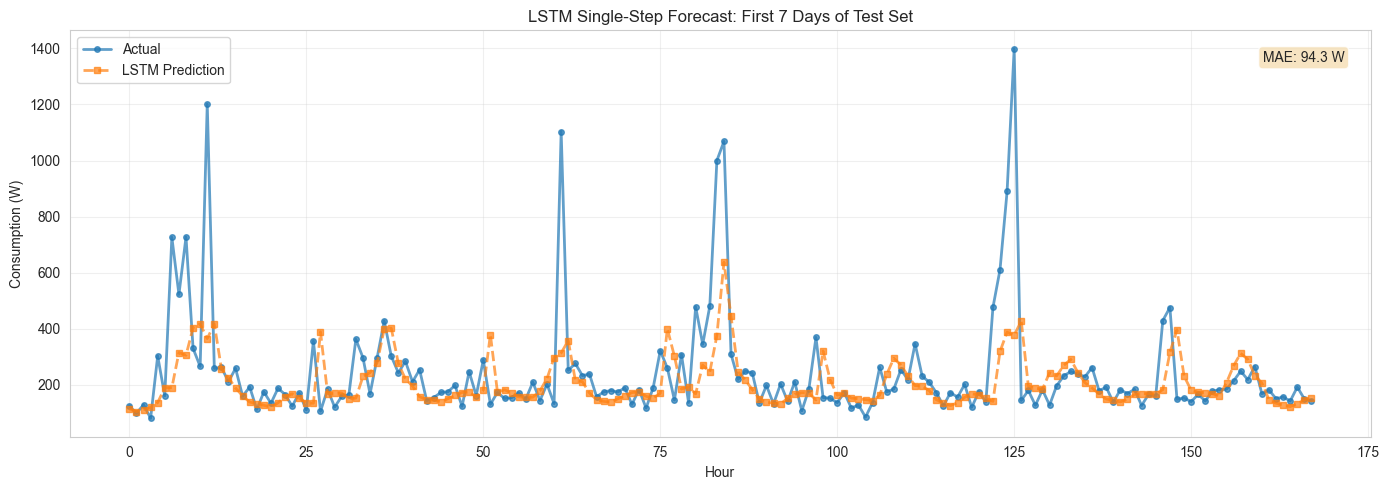

In [17]:
# Plot single-step predictions (first 7 days)
test_subset = slice(0, 7*24)
actual_single = y_test_original[test_subset]
pred_single = lstm_pred_original[test_subset]

fig, ax = plt.subplots(figsize=(14, 5))
hours = range(len(actual_single))
ax.plot(hours, actual_single, 'o-', label='Actual', linewidth=2, markersize=4, alpha=0.7)
ax.plot(hours, pred_single, 's--', label='LSTM Prediction', linewidth=2, markersize=4, alpha=0.7)
ax.set_xlabel('Hour')
ax.set_ylabel('Consumption (W)')
ax.set_title('LSTM Single-Step Forecast: First 7 Days of Test Set')
ax.legend()
ax.grid(True, alpha=0.3)

# Add MAE annotation
ax.text(0.98, 0.95, f'MAE: {lstm_mae:.1f} W', transform=ax.transAxes,
       ha='right', va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

## Notes

The peaks are very hard to model becasue the don't follow a concice statistical pattern. Some thoughts:

- We would need a feature that captures behavioural statistics of households that "warn" or "trigger" before a peak comes
- As discussed previously, the Transformers architecture with its attention mechanism might be able to capture the peaks

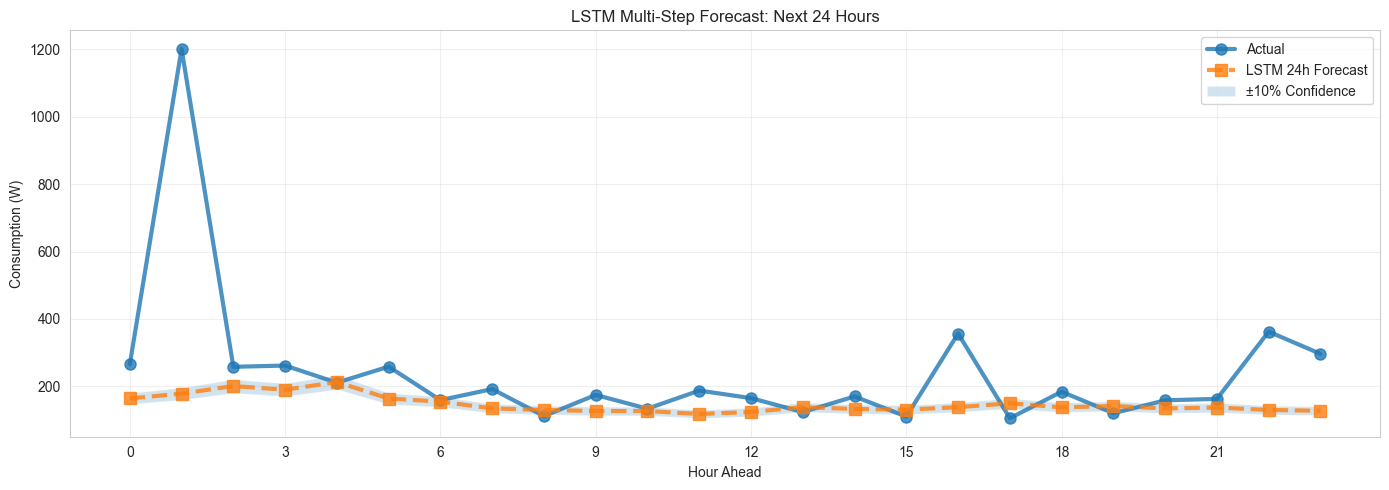

In [18]:
# Plot multi-step forecast example (one 24-hour window)
example_idx = 10
actual_24h = y_test_multi_original[example_idx]
pred_24h = lstm_multi_pred_original[example_idx]

fig, ax = plt.subplots(figsize=(14, 5))
hours_24 = range(24)
ax.plot(hours_24, actual_24h, 'o-', label='Actual', linewidth=3, markersize=8, alpha=0.8)
ax.plot(hours_24, pred_24h, 's--', label='LSTM 24h Forecast', linewidth=3, markersize=8, alpha=0.8)
ax.fill_between(hours_24, pred_24h * 0.9, pred_24h * 1.1, alpha=0.2, label='±10% Confidence')
ax.set_xlabel('Hour Ahead')
ax.set_ylabel('Consumption (W)')
ax.set_title('LSTM Multi-Step Forecast: Next 24 Hours')
ax.set_xticks(range(0, 24, 3))
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 8. Compare LSTM vs Block 1 Models

Let's compare LSTM performance with XGBoost from Block 1

In [19]:
# Build simple XGBoost for comparison (same test set)
from xgboost import XGBRegressor

# Prepare flat features for XGBoost (flatten sequences)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Train XGBoost
xgb_model = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train_flat, y_train.flatten(), verbose=False)

# Predict
xgb_pred_scaled = xgb_model.predict(X_test_flat)

# Inverse transform
xgb_pred_full = np.zeros((len(xgb_pred_scaled), len(feature_cols)))
xgb_pred_full[:, 0] = xgb_pred_scaled
xgb_pred_original = np.exp(scaler.inverse_transform(xgb_pred_full))[:, 0]

# Metrics
xgb_mae = mean_absolute_error(y_test_original, xgb_pred_original)
xgb_rmse = np.sqrt(mean_squared_error(y_test_original, xgb_pred_original))
xgb_r2 = r2_score(y_test_original, xgb_pred_original)

print("XGBoost Performance (for comparison):")
print(f"  MAE:  {xgb_mae:.2f} W")
print(f"  RMSE: {xgb_rmse:.2f} W")
print(f"  R²:   {xgb_r2:.3f}")

XGBoost Performance (for comparison):
  MAE:  91.54 W
  RMSE: 213.13 W
  R²:   0.252


In [20]:
# Comparison table
comparison = pd.DataFrame({
    'Model': ['LSTM (1h ahead)', 'LSTM (24h ahead)', 'XGBoost (1h ahead)'],
    'MAE (W)': [lstm_mae, lstm_multi_mae, xgb_mae],
    'RMSE (W)': [lstm_rmse, lstm_multi_rmse, xgb_rmse],
    'R²': [lstm_r2, lstm_multi_r2, xgb_r2]
})

print("\n" + "="*70)
print("MODEL COMPARISON: LSTM vs XGBoost")
print("="*70)
print(comparison.to_string(index=False))
print("="*70)

# Winner for single-step
if lstm_mae < xgb_mae:
    improvement = (xgb_mae - lstm_mae) / xgb_mae * 100
    print(f"\n🏆 LSTM wins for single-step forecasting!")
    print(f"   {improvement:.1f}% better MAE than XGBoost")
else:
    improvement = (lstm_mae - xgb_mae) / lstm_mae * 100
    print(f"\n🏆 XGBoost wins for single-step forecasting!")
    print(f"   {improvement:.1f}% better MAE than LSTM")

print(f"\n✨ Key Insight:")
print(f"   LSTM can do multi-step forecasting (24h ahead) that XGBoost cannot easily do.")
print(f"   Multi-step MAE: {lstm_multi_mae:.2f} W - still very competitive!")


MODEL COMPARISON: LSTM vs XGBoost
             Model    MAE (W)   RMSE (W)       R²
   LSTM (1h ahead)  94.262534 211.110898 0.265746
  LSTM (24h ahead) 104.590344 231.240463 0.101962
XGBoost (1h ahead)  91.537306 213.134639 0.251601

🏆 XGBoost wins for single-step forecasting!
   2.9% better MAE than LSTM

✨ Key Insight:
   LSTM can do multi-step forecasting (24h ahead) that XGBoost cannot easily do.
   Multi-step MAE: 104.59 W - still very competitive!


# 9. Error Analysis by Forecast Horizon

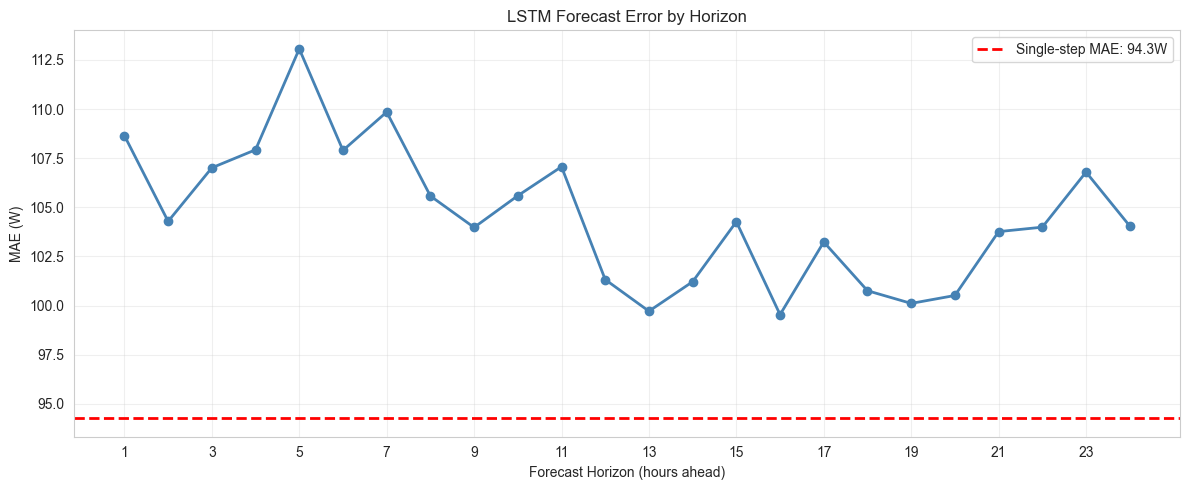


Observation:
  - Error increases with forecast horizon (expected)
  - Short-term (1-6h): MAE ≈ 108.1 W
  - Long-term (18-24h): MAE ≈ 103.2 W


In [21]:
# Plot MAE by forecast horizon
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, forecast_horizon_multi+1), mae_by_hour, 'o-', linewidth=2, markersize=6, color='steelblue')
ax.axhline(y=lstm_mae, color='red', linestyle='--', linewidth=2, label=f'Single-step MAE: {lstm_mae:.1f}W')
ax.set_xlabel('Forecast Horizon (hours ahead)')
ax.set_ylabel('MAE (W)')
ax.set_title('LSTM Forecast Error by Horizon')
ax.set_xticks(range(1, 25, 2))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nObservation:")
print(f"  - Error increases with forecast horizon (expected)")
print(f"  - Short-term (1-6h): MAE ≈ {np.mean(mae_by_hour[:6]):.1f} W")
print(f"  - Long-term (18-24h): MAE ≈ {np.mean(mae_by_hour[18:]):.1f} W")

# 10. Key Takeaways

### What We Learned:

1. **LSTMs Handle Sequences:** Unlike Block 1 models, LSTMs naturally process time series data
2. **Multi-Step Forecasting:** LSTM can predict multiple hours ahead (24h) in one shot
3. **Performance Trade-off:** LSTM may be similar to XGBoost for 1h ahead, but excels at longer horizons
4. **Memory Matters:** LSTM "remembers" patterns from 24+ hours ago (daily cycles)
5. **More Parameters = More Data Needed:** LSTM has ~100K parameters vs XGBoost's implicit structure

### When to Use LSTM vs Traditional ML:

**Use LSTM when:**
- Multi-step forecasting needed (next 24 hours)
- Long-term dependencies critical (weekly/seasonal patterns)
- Sequence structure matters (order of events)
- Large dataset available (LSTM needs more data)

**Use XGBoost/Random Forest when:**
- Single-step forecasting sufficient
- Limited data available
- Interpretability important (feature importance)
- Fast training/inference required

### Business Impact for Hochfrequenz Clients:

- **Grid Operations:** 24h-ahead load forecasting → better unit commitment, lower costs
- **Market Participation:** Multi-step forecasts → optimize day-ahead bidding
- **Customer Services:** Predict tomorrow's consumption → proactive notifications
- **Demand Response:** Forecast peak hours → schedule flexibility programs

---

### Next: Block 3 - Anomaly Detection with Autoencoders
We'll use similar neural network building blocks (encoder-decoder) to detect unusual consumption patterns (fraud, failures, anomalies)!